In [1]:
from matplotlib import pyplot as plt
from func import *
import nn4n
import numpy as np
from rtgym.utils.data_processing import RatemapAggregator
from rtgym.utils.visualization import plot_ratemaps
import torch
from torch.utils.data import DataLoader, TensorDataset

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [3]:
# ===========================================================================================
# Load the input and the label
# ===========================================================================================

load_data_type = '2TS_vary5'
load_dir = f'../data/'
data = np.load(f'{load_dir}/{load_data_type}.npy', allow_pickle=True).item()

train_inputs = torch.tensor(data['train_inputs'], dtype=torch.float32).to(device)
train_labels = torch.tensor(data['train_labels'], dtype=torch.float32).to(device)

# Create DataLoader for training and testing
train_dataset = TensorDataset(train_inputs, train_labels)
train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)

In [4]:
# ===========================================================================================
# Initialise the RNN
# ===========================================================================================
num_neuron = 512

model_cfg = {
            "input_dim":    train_inputs.shape[2],
            "hidden_dim":   num_neuron,
            'output_dim':   train_inputs.shape[2],
            "alpha":        0.1,
            "learn_alpha":  False,
            "preact_noise": 0.4,
            "postact_noise":0.3
            }


rnn = nn4n.nn.RNN(
      # Input laters (multiple recurrent layers)
      recurrent_layers=[# 1st recurrent layer
                        nn4n.nn.RecurrentLayer(
                        projection_layer=nn4n.nn.LinearLayer(
                                         input_dim=model_cfg["input_dim"],
                                         output_dim=model_cfg["hidden_dim"]
                                         ),
                        leaky_layer=nn4n.nn.LeakyLinearLayer(
                                    # input_dim=model_cfg["hidden_dim"],
                                    # output_dim=model_cfg["hidden_dim"],
                                    # ----------------------------------------
                                    linear_layer=nn4n.nn.LinearLayer(
                                        input_dim=model_cfg["hidden_dim"],
                                        output_dim=model_cfg["hidden_dim"]),
                                    # ----------------------------------------
                                    activation=torch.nn.ReLU(),
                                    alpha=model_cfg["alpha"],
                                    learn_alpha=model_cfg["learn_alpha"],
                                    preact_noise=model_cfg["preact_noise"],
                                    postact_noise=model_cfg["postact_noise"]
                                    )
                        )
                        # 2nd recurrent layer (None)
                        ],
      # Output layer
      readout_layer=nn4n.nn.LinearLayer(
                    input_dim=model_cfg["hidden_dim"],
                    output_dim=model_cfg["output_dim"]
                    )
      )
rnn.to(device)


def custom_loss(recon, target, firing_rates, lambda_mse, lambda_r):
    """
    Args:
        recon: [batch, time, dim] — reconstructed experience vectors (ŷ)
        target: [batch, time, dim] — ground truth experience vectors (y)
        firing_rates: [batch, time, N] — firing rates of all hidden neurons
    """

    # Shape values
    B, T, D = target.shape
    N = firing_rates[0].shape[2]

    # 1. Reconstruction MSE Loss
    mse = torch.sum((recon - target) ** 2) / (B * T * D)
    # mse = torch.nn.MSELoss()
    # mse = mse(recon, target)

    # 2. Firing rate regularization term
    reg = torch.sum(torch.sum(firing_rates[0], axis=(0,1))**2 / (B * T)) / N

    total_loss = lambda_mse * mse + lambda_r * reg
    # print(lambda_mse * mse, lambda_r * reg)
    return total_loss, lambda_mse * mse, lambda_r * reg


optimizer = torch.optim.Adam(rnn.parameters(), lr=0.0005) 

In [5]:
# ===========================================================================================
# Train the RNN
# ===========================================================================================
from tqdm import tqdm

rnn.train()

losses = []

for epoch in tqdm(range(5000)):

    for batch_inputs, batch_labels in train_loader:
        
        optimizer.zero_grad()
        batch_outputs, batch_hidden = rnn(batch_inputs)
        
        # loss = criterion(batch_outputs, batch_labels)
        loss, loss1, loss2 = custom_loss(batch_outputs, batch_labels, batch_hidden, lambda_mse=1, lambda_r=0.0001
                           ) 
        loss.backward()
        
        optimizer.step()
        losses.append(loss.item())
        
    if epoch % 100 == 0:
        print(f'Epoch {epoch} Loss {loss.item()}')
        print(loss1, loss2)
    # if loss1 < 0.02:
    #     print("Early stopping due to low MSE loss.")
    #     break
    if len(losses) > 50 and abs(losses[-1] - losses[-50]) < 1e-4 and losses[-1] < 0.1:
        print("Early stopping due to convergence.")
        break
    
print("Training complete.")

  0%|          | 2/5000 [00:00<21:35,  3.86it/s]

Epoch 0 Loss 49.74451446533203
tensor(38.2835, device='cuda:0', grad_fn=<MulBackward0>) tensor(11.4610, device='cuda:0', grad_fn=<MulBackward0>)


  2%|▏         | 102/5000 [00:15<12:03,  6.77it/s]

Epoch 100 Loss 1.2501941919326782
tensor(1.0228, device='cuda:0', grad_fn=<MulBackward0>) tensor(0.2274, device='cuda:0', grad_fn=<MulBackward0>)


  4%|▍         | 202/5000 [00:30<11:46,  6.79it/s]

...

Epoch 4800 Loss 0.2325969934463501
tensor(0.1883, device='cuda:0', grad_fn=<MulBackward0>) tensor(0.0443, device='cuda:0', grad_fn=<MulBackward0>)


 98%|█████████▊| 4902/5000 [12:04<00:14,  6.77it/s]

Epoch 4900 Loss 0.23848706483840942
tensor(0.1942, device='cuda:0', grad_fn=<MulBackward0>) tensor(0.0443, device='cuda:0', grad_fn=<MulBackward0>)


100%|██████████| 5000/5000 [12:18<00:00,  6.77it/s]

Training complete.


In [6]:
# ===========================================================================================
# Test the RNN
# ===========================================================================================

test_inputs = torch.tensor(data['test_inputs'], dtype=torch.float32).to(device)

rnn.eval()
with torch.no_grad():
    test_outputs_from_RNN, hidden_states_from_RNN = rnn(test_inputs)

test_outputs = test_outputs_from_RNN.cpu().numpy()
hidden_states = hidden_states_from_RNN[0].cpu().numpy()
print('test outputs:',  type(test_outputs),  test_outputs.shape)
print('hidden states:', type(hidden_states), hidden_states.shape)

test outputs: <class 'numpy.ndarray'> (50, 100, 100)
hidden states: <class 'numpy.ndarray'> (50, 100, 512)


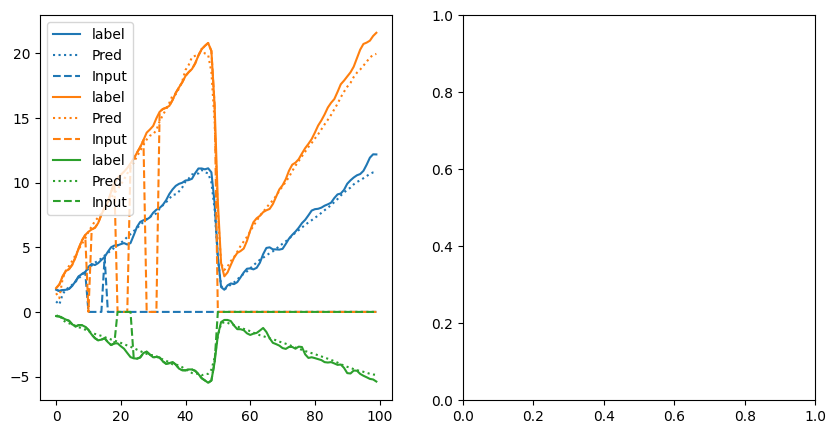

In [7]:
# Plot the test outputs vs the test labels
test_inputs = data['test_inputs']
test_labels = data['test_labels']
fig, ax = plt.subplots(1,2, figsize=(10,5))
for i in range(3):
    ax[0].plot(test_labels[0,:,i], label='label', color=f'C{i}')
    ax[0].plot(test_outputs[0,:,i], label='Pred', linestyle='dotted', color=f'C{i}')
    ax[0].plot(test_inputs[0,:,i], label='Input', linestyle='--', color=f'C{i}')
ax[0].legend()

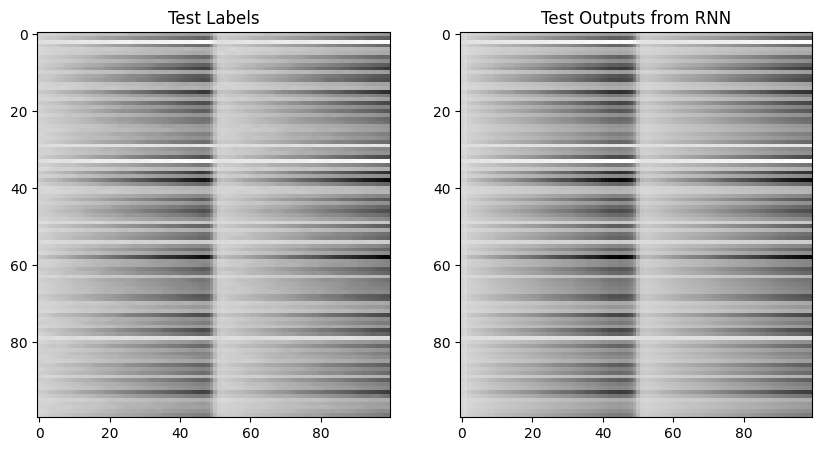

In [8]:
# Plot the test outputs vs the test labels
test_labels = data['test_labels']
fig, ax = plt.subplots(1,2, figsize=(10,5))
ax[0].imshow(test_labels[0].T, aspect='auto', cmap='binary')
ax[0].set_title('Test Labels')
ax[1].imshow(test_outputs[0].T, aspect='auto', cmap='binary')
ax[1].set_title('Test Outputs from RNN')
plt.show()

(100, 512)


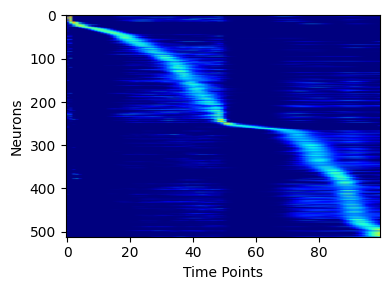

In [9]:
# Averge accross the batch
avg_hs = np.mean(hidden_states, axis=0)
print(avg_hs.shape)
# pre and post noise = 0.5, fr
norm_hs, fig, ax = plt_hs(avg_hs, min_fr=0.1)

(100, 512)
Correlation coefficient: 0.06432962569273942


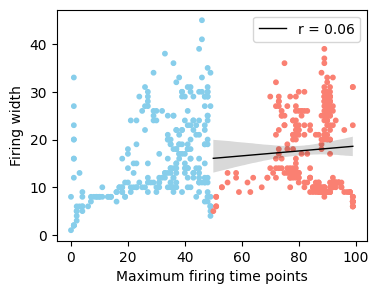

In [10]:
# Spatial task
print(norm_hs.shape)
# Sort the norm_hs with maximum firing time
max_times = np.argmax(norm_hs, axis=0)
# Get the temporal firing width of each neuron, the threshold is 0.1 of the maximum firing rate
firing_widths = np.zeros(norm_hs.shape[1])
for i in range(norm_hs.shape[1]):
    firing_widths[i] = np.sum(norm_hs[:, i] > 1E-1)
    # firing_widths[i] = np.sum(norm_hs[:, i] > 0.1 * np.max(norm_hs[:, i]))
# Plot the firing widths vs the maximum firing times
plt.figure(figsize=(4,3))
# Max time < 50: skyblue
# Max time > 50: salmon
colors = ['skyblue' if t < 50 else 'salmon' for t in max_times]
plt.scatter(max_times, firing_widths, c=colors, 
            s=10)
# use seaborn to plot the correlation of red dots with shaded area
import seaborn as sns
rval = np.corrcoef(max_times[max_times >= 50], firing_widths[(max_times >= 50)])[0,1]
print(f'Correlation coefficient: {rval}')
sns.regplot(x=max_times[(max_times >= 50)], 
            y=firing_widths[(max_times >= 50)],
            scatter=False, 
            color='black',
            line_kws={"linewidth":1, "linestyle":"-"},
            ci=95,
            label=f'r = {rval:.2f}')
plt.xlabel('Maximum firing time points')
plt.ylabel("Firing width")
plt.legend()
plt.show()

In [ ]:
# print(norm_hs.shape)
# # # Crop norm hs
# # norm_hs = norm_hs[30:75, :] 
# # Sort the norm_hs with maximum firing time
# max_times = np.argmax(norm_hs, axis=0)
# # Get the temporal firing width of each neuron, the threshold is 0.1 of the maximum firing rate
# firing_widths = np.zeros(norm_hs.shape[1])
# for i in range(norm_hs.shape[1]):
#     firing_widths[i] = np.sum(norm_hs[:, i] > 1E-1)
#     # firing_widths[i] = np.sum(norm_hs[:, i] > 0.1 * np.max(norm_hs[:, i]))
# # Plot the firing widths vs the maximum firing times
# plt.figure(figsize=(4,3))
# # Max time < 25:      blue
# # 25 < Max time < 30: red
# # 30 < Max time < 75: green
# # 75 < Max time < 80: red
# # 80 < Max time:      blue 
# colors = np.zeros(max_times.shape[0], dtype=object)
# colors[max_times < 25] = 'skyblue'
# # colors[(max_times >= 25) & (max_times < 30)] = 'salmon'
# # colors[(max_times >= 30) & (max_times < 75)] = 'palegreen'
# colors[(max_times >= 25) & (max_times < 80)] = 'salmon'
# colors[max_times >= 80] = 'skyblue'
# plt.scatter(max_times, firing_widths, c=colors, 
#             s=10)
# # use seaborn to plot the correlation of red dots with shaded area
# import seaborn as sns
# rval = np.corrcoef(max_times[(max_times >= 25) & (max_times < 80)], 
#                    firing_widths[(max_times >= 25) & (max_times < 80)])[0,1]
# print(f'Correlation coefficient: {rval}')
# sns.regplot(x=max_times[(max_times >= 25) & (max_times < 80)], 
#             y=firing_widths[(max_times >= 25) & (max_times < 80)],
#             scatter=False, 
#             color='black',
#             line_kws={"linewidth":1, "linestyle":"-"},
#             ci=95,
#             label=f'r = {rval:.2f}')
# plt.xlabel('Maximum firing time points')
# plt.ylabel("Firing width")
# plt.legend()
# plt.show()

In [11]:
data[f'loss_{model_cfg["hidden_dim"]}'] = losses
data[f'test_outputs_{model_cfg["hidden_dim"]}'] = test_outputs
data[f'hidden_states_{model_cfg["hidden_dim"]}'] = hidden_states
print(data.keys())

dict_keys(['train_inputs', 'train_labels', 'test_inputs', 'test_labels', 'arena_map', 'train_traj', 'test_traj', 'loss_512', 'test_outputs_512', 'hidden_states_512'])


In [12]:
np.save(f'{load_dir}/{load_data_type}.npy', data, allow_pickle=True)